In [1]:
from pathlib import Path
import sys
import numpy as np
from OMPython import ModelicaSystem

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from docs.plot_setup import set_professional_style
plt = set_professional_style()

from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum
from MyModels.MasterPendulum.pendulum_ode import PendulumODE, ramp_torque, constant_torque, zero_torque

In [2]:
# FMU Pendulum
fmu_pendulum_path = Path.cwd().parent / 'FMUs/Pendulum.fmu'
eqb_pendulum     = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)

# OpenSim Pendulum
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

# FEM Pendulum with master configuration
fem_pendulum = FEMPendulum(name="FEM_Pendulum", group="Plant")
mesh_params = config.MeshParameters()

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 20  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 0 # Nm

mat_params = config.MaterialParameters()
mat_params.E_pendulum = 2.1e11  # Young's modulus for the pendulum
mat_params.nu_pendulum = 0.3  # Poisson's ratio for the pendulum
mat_params.rho_pendulum = 7800  # Density for the pendulum

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = True
sim_params.use_gravity = True

contact_params = config.ContactParameters()
contact_params.kn = 1e10

anim_params = config.AnimationParameters()
anim_params.animate = False

fem_pendulum.set_parameters(
    mat_params=mat_params,
    contact_params=contact_params,
    init_params=init_params,
    sim_params=sim_params,
    anim_params=anim_params,
    mesh_params=mesh_params
)

pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = fem_pendulum.sim_params.tau
t_end = fem_pendulum.sim_params.t_end

pendulum.initialize(t)
pendulum.setup_monitoring()
pendulum.display_monitoring()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

**Monolithic Reference Solution - Modelica**

In [3]:
# 1) Build the Modelica Model
pkg_dir_path = Path.cwd().parent / 'Modelica/ControlledPendulum'
pkg_file_path = pkg_dir_path / 'package.mo'
model = 'ControlledPendulum.PendulumWithWallContinuous'

# 2) Create Modelica System Model
model = ModelicaSystem(str(pkg_file_path), model)

# 3) Set Model Parameters
parameters =[
    f"pendulum.L={fem_pendulum._equivalent_length}",
    f"pendulum.m={fem_pendulum.mass}",
    f"pendulum.inertia={fem_pendulum.inertia}",
    f"pendulum.q0={q0}",
    f"wall.c={0}",
    f"wall.k={contact_params.kn}"
]
model.setParameters(parameters)

# 4) Set simulation options
t0 = 0.0
dt_monolithic = 1e-4
solver_tolerance = 1e-8
solver_monolithic = 'dassl'
simulation_options = [
    f'startTime={t0}',
    f'stopTime={t_end}',
    f'stepSize={dt_monolithic}',
    f'tolerance={solver_tolerance}',
    f'solver={solver_monolithic}'
]
model.setSimulationOptions(simulation_options)

# 5) Build model
model.buildModel()

# 6) Run simulation
model.simulate()

# 7) Retrieve results
ref_monolithic = {}
keys = ('time', 'pendulum.q', 'pendulum.omega', 'pendulum.alpha')
for key in keys:
    print('Extracting: ', key)
    ref_monolithic[key] = model.getSolutions(key)
    ref_monolithic[key] = ref_monolithic[key].flatten()

t_an_m_vals = ref_monolithic['time']
q_an_m_vals = ref_monolithic['pendulum.q']
omega_an_m_vals = ref_monolithic['pendulum.omega']
alpha_an_m_vals = ref_monolithic['pendulum.alpha']


Notification: Automatically loaded package Complex 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package ModelicaServices 4.0.0 due to uses annotation from Modelica.
Notification: Automatically loaded package Modelica 4.0.0 due to usage.


LOG_STDOUT        | warning | You are overriding wall.c with a small value or zero.
|                 | |       | This could lead to numerically dirty solutions or divisions by zero if not tearingStrictness=veryStrict.
LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.
Extracting:  time
Extracting:  pendulum.q
Extracting:  pendulum.omega
Extracting:  pendulum.alpha


**FMU Reference Solution**

In [4]:
fmu_pendulum_wall_path = Path.cwd().parent / 'FMUs/PendulumWithWallContinuous.fmu'
fmu_pendulum_wall = FMUComponent(name="FMU_Pendulum_Wall", fmu_path=fmu_pendulum_wall_path)

fmu_pendulum_wall.parameters['pendulum.L'].start = fem_pendulum._equivalent_length
fmu_pendulum_wall.parameters['pendulum.m'].start = fem_pendulum.mass
fmu_pendulum_wall.parameters['pendulum.inertia'].start = fem_pendulum.inertia
fmu_pendulum_wall.parameters['pendulum.q0'].start = q0

fmu_pendulum_wall.parameters['wall.c'].start = 0
fmu_pendulum_wall.parameters['wall.k'].start = contact_params.kn
fmu_pendulum_wall.parameters['wall.q_wall'].start = 0

t = 0.0
fmu_pendulum_wall.initialize(t)

dt_an = 1e-4
for _ in range(int(t_end/dt_an)):
    fmu_pendulum_wall.do_step(t=t, dt=dt_an)
    t += dt_an

ref_sol_hist = fmu_pendulum_wall.get_history()
t_an_fmu_vals = ref_sol_hist['q']['time']
q_an__fmu_vals = ref_sol_hist['q']['values']
omega_an_fmu_vals = ref_sol_hist['omega']['values']
alpha_an_fmu_vals = ref_sol_hist['alpha']['values']

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [5]:
t = 0.0
while t < t_end:
    # 1) Integrate one time step
    pendulum.do_step(t, dt)

    # 2) Advance time
    t += dt

[Pendulum] Switching: EQB to FEM @ t=0.3700s
[Pendulum] Switching: FEM to EQB @ t=0.5100s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detect

In [6]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict['alpha']
    omega_vals[mode] = res_dict['omega']
    q_vals[mode]     = res_dict['q']

In [7]:
rel_errors_fmu = {mode: {'q': [], 'omega': [], 'alpha': []} for mode in pendulum.models.keys()}
rel_errors_m = {mode: {'q': [], 'omega': [], 'alpha': []} for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    # Interpolate analytical solution to the time points of the model
    t_num = t_vals[mode]
    q_an_interp = np.interp(t_num, t_an_fmu_vals, q_an__fmu_vals)
    omega_an_interp = np.interp(t_num, t_an_fmu_vals, omega_an_fmu_vals)
    alpha_an_interp = np.interp(t_num, t_an_fmu_vals, alpha_an_fmu_vals)

    q_an_m_interp = np.interp(t_num, t_an_m_vals, q_an_m_vals)
    omega_an_m_interp = np.interp(t_num, t_an_m_vals, omega_an_m_vals)
    alpha_an_m_interp = np.interp(t_num, t_an_m_vals, alpha_an_m_vals)
    
    # Calculate relative errors
    eps = 1e-12
    q_num = q_vals[mode]
    omega_num = omega_vals[mode]
    alpha_num = alpha_vals[mode]
    rel_errors_fmu[mode]['q'] = np.abs(q_num - q_an_interp) / np.max(np.abs(q_an_interp))
    rel_errors_fmu[mode]['omega'] = np.abs(omega_num - omega_an_interp) / np.max(np.abs(omega_an_interp))
    rel_errors_fmu[mode]['alpha'] = np.abs(alpha_num - alpha_an_interp) / np.max(np.abs(alpha_an_interp))

    rel_errors_m[mode]['q'] = np.abs(q_num - q_an_m_interp) / np.max(np.abs(q_an_m_interp))
    rel_errors_m[mode]['omega'] = np.abs(omega_num - omega_an_m_interp) / np.max(np.abs(omega_an_m_interp))
    rel_errors_m[mode]['alpha'] = np.abs(alpha_num - alpha_an_m_interp) / np.max(np.abs(alpha_an_m_interp))

In [8]:
marker_size = 3
fem_style = {'color': "#063ccf", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'FEM'}
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'OpenSim'}  # Green
eqb_style = {'color': "#24aa09", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'EQB'}  # Purple
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

fig_size = (9, 9)
y_suptitle = 1.04
y_subtitle = 1
y_legend = 0.99
top_adjust = 0.9

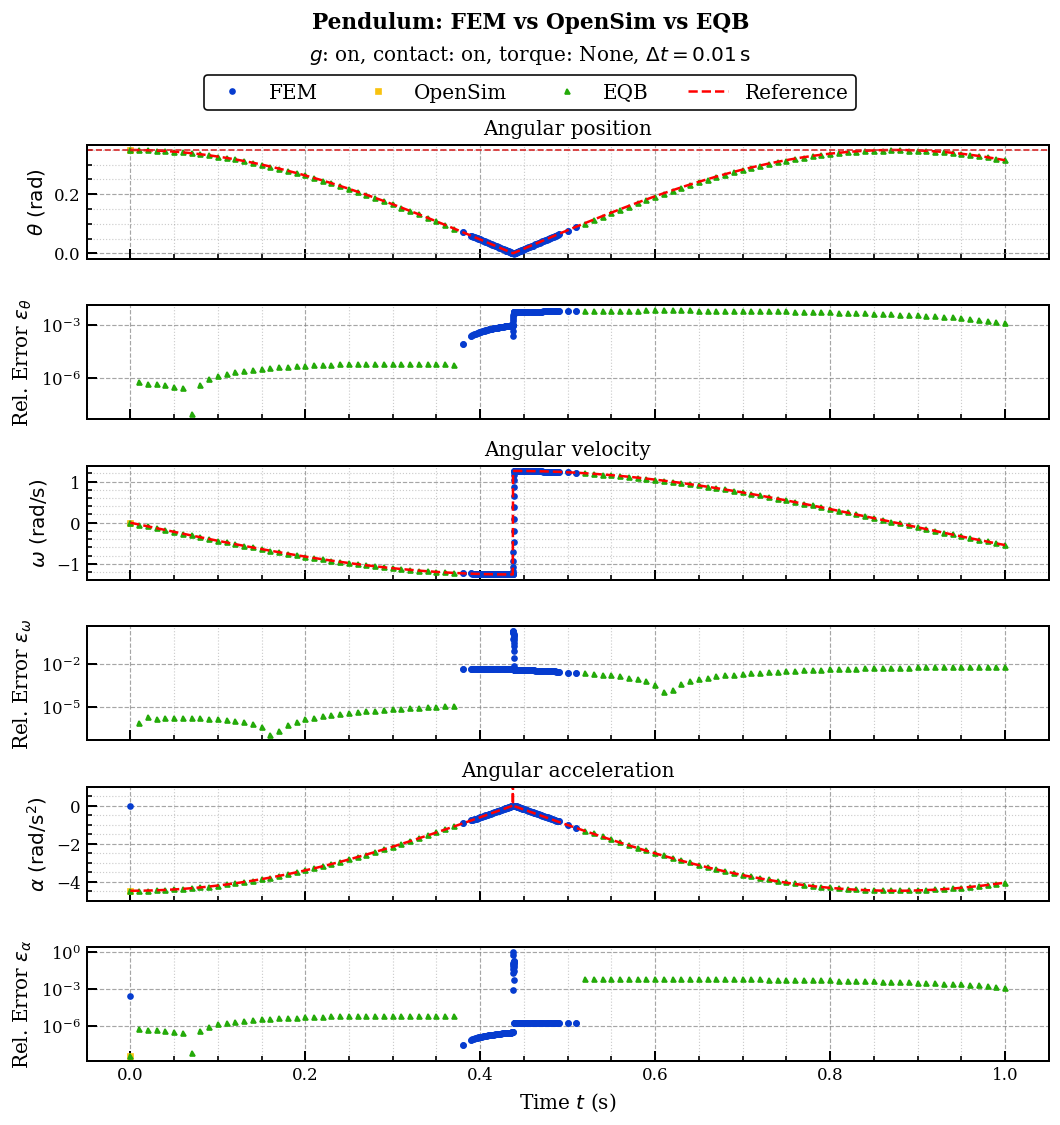

In [9]:
fig, axs = plt.subplots(6, 1, figsize=fig_size, sharex=True)

main_title = "Pendulum: FEM vs OpenSim vs EQB"
fig.suptitle(main_title, fontsize=13, fontweight='bold', y=y_suptitle)
param_str = (
    rf"$g$: {'on' if sim_params.use_gravity else 'off'}, "
    rf"contact: {'on' if sim_params.with_contact else 'off'}, "
    rf"torque: None, "
    rf"$\Delta t = {dt}\,\mathrm{{s}}$"
)
fig.text(0.5, y_subtitle, param_str, ha='center', va='center')

rel_errors = rel_errors_m  # Use Modelica-based analytical solution for error calculation

axs[0].set_title(r'Angular position')
line_fem_q,      = axs[0].plot(t_vals['FEM'],     q_vals['FEM'],     **fem_style)
line_osim_q,     = axs[0].plot(t_vals['OpenSim'], q_vals['OpenSim'], **opensim_style)
line_eqb_q,      = axs[0].plot(t_vals['EQB'],     q_vals['EQB'],     **eqb_style)
line_analytical_q, = axs[0].plot(t_an_m_vals, q_an_m_vals, label='Reference', color='red', linestyle='--', linewidth=1.5)
axs[0].axhline(q0, color='tab:red', linestyle='--', linewidth=1.0)
axs[0].set_ylabel(r'$\theta\ \mathrm{(rad)}$')

axs[1].semilogy(t_vals['FEM'][1:],     rel_errors['FEM']['q'][1:],     **fem_style)
axs[1].semilogy(t_vals['OpenSim'], rel_errors['OpenSim']['q'], **opensim_style)
axs[1].semilogy(t_vals['EQB'],     rel_errors['EQB']['q'],     **eqb_style)
axs[1].set_ylabel(r'Rel. Error $\epsilon_\theta$')

axs[2].set_title(r'Angular velocity')
axs[2].plot(t_vals['FEM'],     omega_vals['FEM'],     **fem_style)
axs[2].plot(t_vals['OpenSim'], omega_vals['OpenSim'], **opensim_style)
axs[2].plot(t_vals['EQB'],     omega_vals['EQB'],     **eqb_style)
axs[2].plot(t_an_m_vals, omega_an_m_vals, color='red', linestyle='--', linewidth=1.5)
axs[2].set_ylabel(r'$\omega\ \mathrm{(rad/s)}$')

axs[3].semilogy(t_vals['FEM'],     rel_errors['FEM']['omega'],     **fem_style)
axs[3].semilogy(t_vals['OpenSim'], rel_errors['OpenSim']['omega'], **opensim_style)
axs[3].semilogy(t_vals['EQB'],     rel_errors['EQB']['omega'],     **eqb_style)
axs[3].set_ylabel(r'Rel. Error $\epsilon_\omega$')

axs[4].set_title(r'Angular acceleration')
axs[4].plot(t_vals['FEM'],     alpha_vals['FEM'],     **fem_style)
axs[4].plot(t_vals['OpenSim'], alpha_vals['OpenSim'], **opensim_style)
axs[4].plot(t_vals['EQB'],     alpha_vals['EQB'],     **eqb_style)
axs[4].plot(t_an_m_vals, alpha_an_m_vals, color='red', linestyle='--', linewidth=1.5)
axs[4].set_ylim([-5, 1])
axs[4].set_ylabel(r'$\alpha\ \mathrm{(rad/s^2)}$')

axs[5].semilogy(t_vals['FEM'],     rel_errors['FEM']['alpha'],     **fem_style)
axs[5].semilogy(t_vals['OpenSim'], rel_errors['OpenSim']['alpha'], **opensim_style)
axs[5].semilogy(t_vals['EQB'],     rel_errors['EQB']['alpha'],     **eqb_style)
axs[5].set_ylabel(r'Rel. Error $\epsilon_\alpha$')

axs[5].set_xlabel(r'Time $t$ (s)')

handles = [line_fem_q, line_osim_q, line_eqb_q, line_analytical_q]
labels  = [h.get_label() for h in handles]

fig.legend(handles, labels,
           loc='upper center',
           bbox_to_anchor=(0.5, y_legend),
           ncol=4,
           frameon=True)

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major', linestyle='--', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)

plt.subplots_adjust(top=top_adjust)
plt.tight_layout()
#plt.savefig("../figures/StateSynchronization_impact.svg")
plt.show()


In [10]:
import tabulate
import pandas as pd

# Create DataFrame for better handling
sync_data = []

for event in pendulum.sync_events:
    # Extract values
    time = event['time']
    from_mode = event['from_mode']
    to_mode = event['to_mode']
    
    ret = event['retrieved']
    new = event['now']
    
    # Helper to extract magnitude
    def get_val(x):
        if hasattr(x, 'magnitude'):
            return x.magnitude
        return float(x) if hasattr(x, '__float__') else x
    
    sync_data.append({
        'Time (s)': f"{time:.4f}",
        'Transition': f"{from_mode} → {to_mode}",
        'θ_ret (°)': f"{np.rad2deg(get_val(ret['q']['value'])):.2f}",
        'ω_ret': f"{get_val(ret['omega']['value']):.3f}",
        'α_ret': f"{get_val(ret['alpha']['value']):.1f}",
        'τ_ret': f"{get_val(ret['torque']['value']):.2f}",
        'θ_new (°)': f"{np.rad2deg(get_val(new['q']['value'])):.2f}",
        'ω_new': f"{get_val(new['omega']['value']):.3f}",
        'α_new': f"{get_val(new['alpha']['value']):.1f}",
        'τ_new': f"{get_val(new['torque']['value']):.2f}",
    })

df = pd.DataFrame(sync_data)

print("\n" + "="*140)
print(" "*50 + "MODE SYNCHRONIZATION EVENTS")
print("="*140)
print(tabulate.tabulate(df, headers='keys', tablefmt='grid', showindex=False))
print("="*140)
print(f"Total mode switches: {len(sync_data)}")
print("="*140 + "\n")


                                                  MODE SYNCHRONIZATION EVENTS
+------------+--------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|   Time (s) | Transition   |   θ_ret (°) |   ω_ret |   α_ret |   τ_ret |   θ_new (°) |   ω_new |   α_new |   τ_new |
+============+==============+=============+=========+=========+=========+=============+=========+=========+=========+
|       0.37 | EQB → FEM    |        4.79 |  -1.22  |    -1.1 |       0 |        4.79 |  -1.22  |     0   |       0 |
+------------+--------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
|       0.51 | FEM → EQB    |        5.04 |   1.211 |    -1.2 |       0 |        5.04 |   1.211 |    -1.2 |       0 |
+------------+--------------+-------------+---------+---------+---------+-------------+---------+---------+---------+
Total mode switches: 2

